In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!cp -r "/content/drive/MyDrive/eeg_2/" /content/


In [ ]:
!pip install mne

In [7]:
import mne
import glob
raw = mne.io.read_raw_fif('/content/eeg_2/merged_raw.fif', preload=True, verbose=False)

print(f"\n✅ Merged Raw object has {len(raw.ch_names)} channels and {raw.n_times} total samples.")


✅ Merged Raw object has 30 channels and 147529260 total samples.


In [8]:
raw.filter(l_freq=0.5, h_freq=50.0)
print("Applied 0.5 Hz high-pass and 50 Hz low-pass filters.")

# 2. Downsample the data to 250 Hz
raw.resample(250)
print("Data downsampled to 250 Hz.")

# 3. Print the raw metadata (info)
print("Raw metadata:")
print(raw.info)

Filtering raw data in 62 contiguous segments
Setting up band-pass filter from 0.5 - 50 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 0.50
- Lower transition bandwidth: 0.50 Hz (-6 dB cutoff frequency: 0.25 Hz)
- Upper passband edge: 50.00 Hz
- Upper transition bandwidth: 12.50 Hz (-6 dB cutoff frequency: 56.25 Hz)
- Filter length: 3301 samples (6.602 s)



[Parallel(n_jobs=1)]: Done  17 tasks      | elapsed:    1.8s


Applied 0.5 Hz high-pass and 50 Hz low-pass filters.
Data downsampled to 250 Hz.
Raw metadata:
<Info | 10 non-empty values
 bads: []
 ch_names: FP1, FP2, F7, F3, FZ, F4, F8, FT7, FC3, FCZ, FC4, FT8, T3, C3, ...
 chs: 30 EEG
 custom_ref_applied: False
 dig: 30 items (30 EEG)
 file_id: 4 items (dict)
 highpass: 0.5 Hz
 lowpass: 50.0 Hz
 meas_date: unspecified
 meas_id: 4 items (dict)
 nchan: 30
 projs: []
 sfreq: 250.0 Hz
>


In [9]:
events, event_id = mne.events_from_annotations(raw)
print("Extracted events from annotations:")
print(events)
print("Event IDs:", event_id)

Used Annotations descriptions: [np.str_('251'), np.str_('252'), np.str_('253'), np.str_('254'), np.str_('255')]
Extracted events from annotations:
[[    3099        0        2]
 [    3316        0        3]
 [    3780        0        4]
 ...
 [73761961        0        2]
 [73762852        0        3]
 [73763430        0        4]]
Event IDs: {np.str_('251'): 1, np.str_('252'): 2, np.str_('253'): 3, np.str_('254'): 4, np.str_('255'): 5}


In [10]:
epochs = mne.Epochs(raw, events, tmin=-1, tmax=7, baseline=None, preload=False,event_repeated='merge')
#print("Epochs shape:", epochs.get_data().shape)  # (n_epochs, n_channels, n_times)

Multiple event values for single event times found. Creating new event value to reflect simultaneous events.
Not setting metadata
81439 matching events found
No baseline correction applied
0 projection items activated


In [11]:
import numpy as np
from scipy.signal import hilbert
from itertools import combinations

# --- Load EEG epochs ---
eeg_epochs = epochs.get_data()  # shape: (n_epochs, n_channels, n_times)
  # Change to your dataset's sampling rate

Using data from preloaded Raw for 81439 events and 2001 original time points ...
77 bad epochs dropped


In [12]:


# --- 1. Covariance Features ---
def compute_covariance_features(epochs):
    cov_features = []
    for epoch in epochs:
        cov = np.cov(epoch)  # shape: (n_channels, n_channels)
        upper_tri = cov[np.triu_indices_from(cov, k=1)]  # keep upper triangle only
        cov_features.append(upper_tri)
    return np.array(cov_features)

cov_features = compute_covariance_features(eeg_epochs)
np.save("cov_features.npy", cov_features)



In [13]:
import numpy as np
from scipy.signal import hilbert
from itertools import combinations

def compute_plv_features_fast(epochs):
    """
    Compute PLV for a batch of epochs.
    Input: epochs (n_epochs, n_channels, n_times)
    Output: PLV (n_epochs, n_pairs)
    """
    n_epochs, n_channels, n_times = epochs.shape

    # Pre-compute all channel pairs
    pairs = list(combinations(range(n_channels), 2))
    n_pairs = len(pairs)

    # Compute analytic signal and phase in one step
    # This avoids calling hilbert for each epoch separately
    analytic_signal = hilbert(epochs, axis=2)
    phases = np.angle(analytic_signal)

    # Pre-allocate result array for better memory management
    plv = np.zeros((n_epochs, n_pairs))

    # Vectorized computation for all epochs at once
    for p_idx, (i, j) in enumerate(pairs):
        # Calculate phase difference for all epochs at once
        phase_diff = phases[:, i, :] - phases[:, j, :]
        # Calculate PLV
        plv[:, p_idx] = np.abs(np.mean(np.exp(1j * phase_diff), axis=1))

    return plv

def compute_plv_features_batch(epochs, batch_size=50, save_path="plv_features.npy"):
    """
    Batch-wise PLV computation for large datasets.
    Uses optimized processing and memory management.
    """
    n_epochs = epochs.shape[0]
    n_channels = epochs.shape[1]
    n_pairs = n_channels * (n_channels - 1) // 2

    # Pre-allocate the final array to avoid repeated concatenations
    plv_all = np.zeros((n_epochs, n_pairs))

    # Process in batches
    for start in range(0, n_epochs, batch_size):
        end = min(start + batch_size, n_epochs)
        batch = epochs[start:end]

        # Process batch
        plv_batch = compute_plv_features_fast(batch)

        # Store directly in pre-allocated array
        plv_all[start:end, :] = plv_batch

        print(f"✅ Processed batch {start+1}-{end}/{n_epochs}")

    # Save results
    np.save(save_path, plv_all)
    print(f"✅ PLV features saved to {save_path}")

    return plv_all


# Run batched computation
plv_features = compute_plv_features_batch(eeg_epochs, batch_size=20)

# Print shape after saving
# print(f"PLV shape: {plv_features.shape}")
# --- Save for later use ---
np.save("plv_features.npy", plv_features)

print("✅ Covariance and PLV features extracted and saved!")
print(f"Cov shape: {cov_features.shape} | PLV shape: {plv_features.shape}")


✅ Processed batch 1-20/81362
✅ Processed batch 21-40/81362
✅ Processed batch 41-60/81362
✅ Processed batch 61-80/81362
✅ Processed batch 81-100/81362
✅ Processed batch 101-120/81362
✅ Processed batch 121-140/81362
✅ Processed batch 141-160/81362
✅ Processed batch 161-180/81362
✅ Processed batch 181-200/81362
✅ Processed batch 201-220/81362
✅ Processed batch 221-240/81362
✅ Processed batch 241-260/81362
✅ Processed batch 261-280/81362
✅ Processed batch 281-300/81362
✅ Processed batch 301-320/81362
✅ Processed batch 321-340/81362
✅ Processed batch 341-360/81362
✅ Processed batch 361-380/81362
✅ Processed batch 381-400/81362
✅ Processed batch 401-420/81362
✅ Processed batch 421-440/81362
✅ Processed batch 441-460/81362
✅ Processed batch 461-480/81362
✅ Processed batch 481-500/81362
✅ Processed batch 501-520/81362
✅ Processed batch 521-540/81362
✅ Processed batch 541-560/81362
✅ Processed batch 561-580/81362
✅ Processed batch 581-600/81362
✅ Processed batch 601-620/81362
✅ Processed batch 

In [ ]:
!mkdir -p /content/drive/MyDrive/Feature_eeg

In [22]:
!cp -r "/content/cov_features.npy" /content/drive/MyDrive/Feature_eeg

In [23]:
!cp -r "/content/plv_features.npy" /content/drive/MyDrive/Feature_eeg

Number of epochs with valid RT:  81362


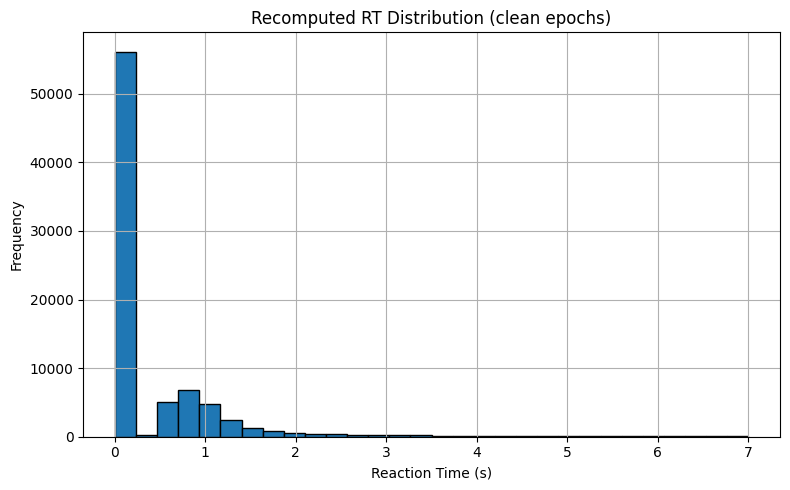

In [15]:
import numpy as np
import matplotlib.pyplot as plt

# --- 1. Re‑use your fast RT‐compute function ---
def fast_compute_reaction_times_and_filter_epochs(epochs, events, event_id, raw):
    sfreq = raw.info['sfreq']
    dev_ids = {event_id['251'], event_id['252']}
    resp_id = event_id['253']

    events_arr      = np.asarray(events)
    response_events = events_arr[events_arr[:, 2] == resp_id]

    tmin_samp = int(epochs.tmin * sfreq)
    tmax_samp = int(epochs.tmax * sfreq)

    rt_all = np.zeros(len(epochs.events))
    for i, ev in enumerate(epochs.events):
        if ev[2] in dev_ids:
            t_do = ev[0]
            start = t_do + tmin_samp
            end   = t_do + tmax_samp

            mask = (response_events[:,0] > start) & (response_events[:,0] <= end)
            resp = response_events[mask]
            if resp.size:
                rt_all[i] = (resp[0,0] - t_do) / sfreq

    return epochs, rt_all

# --- 2. Call it on your cleaned Epochs object (valid_epochs) ---
#    Make sure `valid_epochs` is the MNE Epochs you created with reject=None, etc.
valid_epochs, rt_valid = fast_compute_reaction_times_and_filter_epochs(
    epochs,   # your Epochs with tmin/tmax, no rejection
    events,
    event_id,
    raw
)

np.save("Recation.npy", rt_valid)

# --- 3. Print counts and plot the new RT distribution ---
print(f"Number of epochs with valid RT:  {len(valid_epochs.events)}")


In [21]:
!cp -r "/content/Recation.npy" /content/drive/MyDrive/Feature_eeg